# Proyek Data Engineer Dibimbing: Hotel Bookings

Notebook ini memenuhi tugas utama:
1. Menggunakan dataset raw (`hotel_bookings.csv`)
2. Melakukan data quality check, cleansing, dan filtering
3. Mengekspor hasil ke CSV dan Excel
4. Menerapkan data governance (masking data sensitif + data dictionary)
5. (Opsional) Analisis dasar dan visualisasi

In [1]:
import warnings
warnings.filterwarnings("ignore")

import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

DATA_PATH = Path("hotel_bookings.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data path exists:", DATA_PATH.exists())
print("Output directory:", OUTPUT_DIR.resolve())

Data path exists: True
Output directory: /home/titan/github/de-dibimbing-dsf49/outputs


## 1) Ambil Data Raw
Membaca file CSV mentah dari Kaggle/hasil unduhan: `hotel_bookings.csv`.

In [2]:
df_raw = pd.read_csv(DATA_PATH, na_values=["NULL", "null", ""])

print("Shape data raw:", df_raw.shape)
display(df_raw.head())

Shape data raw: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2) Data Quality Check
Cek struktur data, missing values, duplikasi, dan statistik dasar untuk mendeteksi anomali.

In [3]:
print("Info dataset:")
df_raw.info()

missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
quality_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

duplicate_count = df_raw.duplicated().sum()
print("\nJumlah duplikat baris penuh:", duplicate_count)
print("\nTop missing values:")
display(quality_report.head(15))

numeric_summary = df_raw.describe(include=[np.number]).T
display(numeric_summary)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  me

,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00
arrival_date_month,0,0.00
arrival_date_week_number,0,0.00
hotel,0,0.00
is_canceled,0,0.00
stays_in_weekend_nights,0,0.00
arrival_date_day_of_month,0,0.00


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 3) Data Cleansing & Filtering
Aturan cleansing yang digunakan:
- Hapus duplikat baris penuh
- Konversi tipe data tanggal
- Isi `children` kosong dengan 0
- Buang data anomali yang tidak relevan untuk analisis booking normal:
  - total tamu = 0
  - total malam <= 0
  - nilai ADR (harga harian) negatif

In [4]:
df = df_raw.copy()

df.columns = [c.strip().lower() for c in df.columns]
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], errors="coerce")
df["children"] = df["children"].fillna(0)

df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

before_rows = len(df)
df = df.drop_duplicates().copy()
after_dedup_rows = len(df)

df_clean = df[(df["total_guests"] > 0) & (df["total_nights"] > 0) & (df["adr"] >= 0)].copy()

print(f"Rows sebelum dedup: {before_rows:,}")
print(f"Rows sesudah dedup: {after_dedup_rows:,}")
print(f"Rows sesudah filtering: {len(df_clean):,}")

display(df_clean.head())

Rows sebelum dedup: 119,390
Rows sesudah dedup: 87,396
Rows sesudah filtering: 86,638


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2.0,2
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03,2.0,2
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03,2.0,2


## 4) Data Governance: Masking Data Sensitif
Contoh masking yang diterapkan:
- `agent` dan `company` di-hash (pseudonymization)
- `country` dimasking parsial

In [5]:
def hash_value(value: object, prefix: str = "id") -> object:
    if pd.isna(value):
        return np.nan
    digest = hashlib.sha256(str(value).encode("utf-8")).hexdigest()[:10]
    return f"{prefix}_{digest}"


def mask_country(country: object) -> object:
    if pd.isna(country):
        return np.nan
    country = str(country).strip()
    if len(country) <= 1:
        return "*"
    return country[0] + "*" * (len(country) - 1)


df_governed = df_clean.copy()
df_governed["agent_masked"] = df_governed["agent"].apply(lambda x: hash_value(x, prefix="agent"))
df_governed["company_masked"] = df_governed["company"].apply(lambda x: hash_value(x, prefix="company"))
df_governed["country_masked"] = df_governed["country"].apply(mask_country)

df_governed = df_governed.drop(columns=["agent", "company", "country"])

display(df_governed[["hotel", "agent_masked", "company_masked", "country_masked"]].head())

,hotel,agent_masked,company_masked,country_masked
2,Resort Hotel,NaN,NaN,G**
3,Resort Hotel,agent_9ccdcd4e67,NaN,G**
4,Resort Hotel,agent_4575464f61,NaN,G**
6,Resort Hotel,NaN,NaN,P**
7,Resort Hotel,agent_d8bba3958e,NaN,P**


## 5) Data Dictionary
Membuat data dictionary otomatis berisi nama kolom, tipe data, jumlah nilai kosong, persentase kosong, dan jumlah nilai unik.

In [6]:
column_descriptions = {
    "hotel": "Tipe hotel (Resort/City)",
    "is_canceled": "Status pembatalan booking (1=batal, 0=tidak)",
    "lead_time": "Jumlah hari antara booking dibuat dan check-in",
    "arrival_date_year": "Tahun kedatangan",
    "arrival_date_month": "Bulan kedatangan",
    "arrival_date_week_number": "Minggu keberapa dalam tahun saat kedatangan",
    "arrival_date_day_of_month": "Tanggal kedatangan",
    "stays_in_weekend_nights": "Jumlah malam akhir pekan",
    "stays_in_week_nights": "Jumlah malam weekday",
    "adults": "Jumlah tamu dewasa",
    "children": "Jumlah tamu anak",
    "babies": "Jumlah tamu bayi",
    "meal": "Jenis paket makan",
    "market_segment": "Segmen pasar pemesanan",
    "distribution_channel": "Kanal distribusi pemesanan",
    "is_repeated_guest": "Apakah tamu pernah menginap sebelumnya",
    "previous_cancellations": "Jumlah pembatalan sebelumnya",
    "previous_bookings_not_canceled": "Jumlah booking sebelumnya yang tidak batal",
    "reserved_room_type": "Tipe kamar yang dipesan",
    "assigned_room_type": "Tipe kamar yang diberikan",
    "booking_changes": "Jumlah perubahan booking",
    "deposit_type": "Jenis deposit",
    "days_in_waiting_list": "Jumlah hari di waiting list",
    "customer_type": "Jenis pelanggan",
    "adr": "Average Daily Rate",
    "required_car_parking_spaces": "Jumlah slot parkir yang diminta",
    "total_of_special_requests": "Jumlah permintaan khusus",
    "reservation_status": "Status reservasi akhir",
    "reservation_status_date": "Tanggal update status reservasi",
    "total_guests": "Total tamu dalam booking",
    "total_nights": "Total malam menginap",
    "agent_masked": "ID agent yang sudah di-hash",
    "company_masked": "ID company yang sudah di-hash",
    "country_masked": "Kode negara yang dimasking"
}

dictionary_df = pd.DataFrame({
    "column_name": df_governed.columns,
    "dtype": [str(df_governed[c].dtype) for c in df_governed.columns],
    "null_count": [int(df_governed[c].isna().sum()) for c in df_governed.columns],
    "null_pct": [round(float(df_governed[c].isna().mean() * 100), 2) for c in df_governed.columns],
    "n_unique": [int(df_governed[c].nunique(dropna=True)) for c in df_governed.columns],
    "description": [column_descriptions.get(c, "Deskripsi belum ditambahkan") for c in df_governed.columns]
})

display(dictionary_df)

,column_name,dtype,null_count,null_pct,n_unique,description
0,hotel,object,0,0.00,2,Tipe hotel (Resort/City)
1,is_canceled,int64,0,0.00,2,"Status pembatalan booking (1=batal, 0=tidak)"
2,lead_time,int64,0,0.00,478,Jumlah hari antara booking dibuat dan check-in
3,arrival_date_year,int64,0,0.00,3,Tahun kedatangan
4,arrival_date_month,object,0,0.00,12,Bulan kedatangan
5,arrival_date_week_number,int64,0,0.00,53,Minggu keberapa dalam tahun saat kedatangan
6,arrival_date_day_of_month,int64,0,0.00,31,Tanggal kedatangan
7,stays_in_weekend_nights,int64,0,0.00,17,Jumlah malam akhir pekan
8,stays_in_week_nights,int64,0,0.00,33,Jumlah malam weekday
9,adults,int64,0,0.00,14,Jumlah tamu dewasa


## 6) Export Output ke CSV dan Excel
Output yang dihasilkan:
- `outputs/hotel_bookings_clean.csv`
- `outputs/hotel_bookings_governed.csv`
- `outputs/data_dictionary.csv`
- `outputs/hotel_bookings_output.xlsx` (multi-sheet: cleaned, governed, data_dictionary)

In [7]:
clean_csv = OUTPUT_DIR / "hotel_bookings_clean.csv"
governed_csv = OUTPUT_DIR / "hotel_bookings_governed.csv"
dictionary_csv = OUTPUT_DIR / "data_dictionary.csv"
excel_path = OUTPUT_DIR / "hotel_bookings_output.xlsx"

df_clean.to_csv(clean_csv, index=False)
df_governed.to_csv(governed_csv, index=False)
dictionary_df.to_csv(dictionary_csv, index=False)

try:
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        df_clean.to_excel(writer, index=False, sheet_name="cleaned")
        df_governed.to_excel(writer, index=False, sheet_name="governed")
        dictionary_df.to_excel(writer, index=False, sheet_name="data_dictionary")
    excel_status = "Excel export berhasil"
except Exception as exc:
    excel_status = f"Excel export gagal: {exc}"

print("CSV clean:", clean_csv)
print("CSV governed:", governed_csv)
print("CSV data dictionary:", dictionary_csv)
print("Excel:", excel_path)
print(excel_status)

CSV clean: outputs/hotel_bookings_clean.csv
CSV governed: outputs/hotel_bookings_governed.csv
CSV data dictionary: outputs/data_dictionary.csv
Excel: outputs/hotel_bookings_output.xlsx
Excel export berhasil


## 7) Analisis Dasar & Visualisasi (Opsional)
Visualisasi: cancellation rate per hotel dan tren ADR rata-rata bulanan.

,hotel,cancellation_rate
0,City Hotel,30.21
1,Resort Hotel,23.71


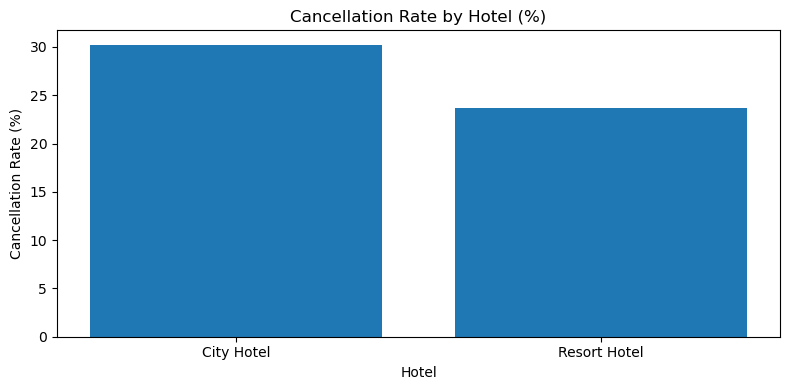

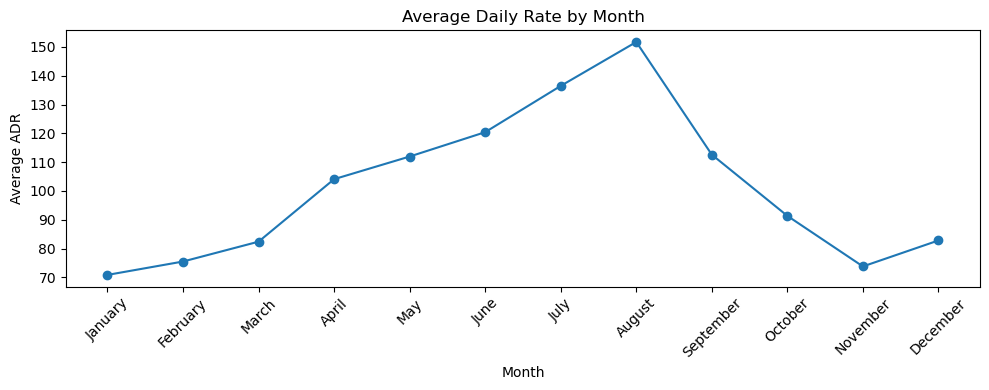

In [8]:
cancel_rate = (
    df_clean.groupby("hotel", as_index=False)["is_canceled"]
    .mean()
    .rename(columns={"is_canceled": "cancellation_rate"})
)
cancel_rate["cancellation_rate"] = (cancel_rate["cancellation_rate"] * 100).round(2)
display(cancel_rate)

plt.figure(figsize=(8, 4))
plt.bar(cancel_rate["hotel"], cancel_rate["cancellation_rate"])
plt.title("Cancellation Rate by Hotel (%)")
plt.xlabel("Hotel")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

adr_month = df_clean.groupby("arrival_date_month", as_index=False)["adr"].mean()
adr_month["arrival_date_month"] = pd.Categorical(adr_month["arrival_date_month"], categories=month_order, ordered=True)
adr_month = adr_month.sort_values("arrival_date_month")

plt.figure(figsize=(10, 4))
plt.plot(adr_month["arrival_date_month"], adr_month["adr"], marker="o")
plt.title("Average Daily Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8) Ringkasan Hasil
- Data sudah melalui quality check, cleansing, dan filtering
- Output berhasil diekspor ke CSV, serta dicoba ekspor ke Excel
- Data governance diterapkan melalui masking data sensitif
- Data dictionary otomatis tersedia sebagai dokumentasi metadata